# Analysis of text complexity

Script for the analyses of text complexity.
The input files are on the Radboud Data Repository in the subfolder './textComplexity'

In [8]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn import metrics

In [9]:
# Make selection of T-Scan measures
selectedVars = ['Let_per_wrd', 'wrd_freq_log_zn_corr', 'wrd_freq_zn_log', 'Wrd_per_zin',  'AL_max',  'MTLD_inhwrd_zonder_abw', 'Inhwrd_dz_zonder_abw', 'Conc_nw_ruim_p', 'Conc_nw_strikt_p', 'Alg_nw_d', 'Pers_ref_d', 'Pers_vnw_d']

In [ ]:
# Read T-Scan measures
basePath = './textComplexity'

child1TScanDF = pd.read_csv(os.path.join(basePath, 'child_story1_TScan_results.csv'), index_col=0).loc[:, selectedVars]
child1TScanDF['Group'] = ['child texts1']*len(child1TScanDF)

adultTScanDF = pd.read_csv(os.path.join(basePath, 'adultTScan_results.csv'), index_col=0).loc[:, selectedVars]
adultTScanDF['Group'] = ['adult texts']*len(adultTScanDF)

# Combine the three DFs in one DF
df = pd.concat([child1TScanDF, adultTScanDF]).reset_index()
df.head(3)

,index,Let_per_wrd,wrd_freq_log_zn_corr,wrd_freq_zn_log,Wrd_per_zin,AL_max,MTLD_inhwrd_zonder_abw,Inhwrd_dz_zonder_abw,Conc_nw_ruim_p,Conc_nw_strikt_p,Alg_nw_d,Pers_ref_d,Pers_vnw_d,Group
0,input/AVI9_story1_orig.prompt.txt,4.33929,4.86747,4.82545,11.20000,6.40000,229.727,3.80000,0.711538,0.519231,17.8571,120.536,98.2143,child texts1
1,input/AVI1_story1_orig.prompt.txt,3.20388,5.44477,5.44477,5.72222,1.44444,30.750,1.95238,0.846154,0.576923,0.0000,106.796,67.9612,child texts1
2,input/AVI5_story1_orig.prompt.txt,4.08485,5.04876,5.03287,7.50000,2.50000,76.880,2.13793,0.566667,0.433333,0.0000,175.758,127.2730,child texts1


In [12]:
# Scale the combined DF
scaler = StandardScaler()
df_vars_scaled = pd.DataFrame(scaler.fit_transform(df.loc[:, selectedVars]), columns = selectedVars)
df_scaled = pd.concat([df_vars_scaled, df.loc[:, ['index', 'Group']]], axis=1)
df_scaled

,Let_per_wrd,wrd_freq_log_zn_corr,wrd_freq_zn_log,Wrd_per_zin,AL_max,MTLD_inhwrd_zonder_abw,Inhwrd_dz_zonder_abw,Conc_nw_ruim_p,Conc_nw_strikt_p,Alg_nw_d,Pers_ref_d,Pers_vnw_d,index,Group
0,-0.828763,0.509346,0.536413,-0.400779,0.719612,-0.694709,0.750803,0.460825,0.305282,0.324083,-0.553533,0.030546,input/AVI9_story1_orig.prompt.txt,child texts1
1,-3.805588,2.247354,2.309047,-1.730794,-2.018550,-1.526156,-1.599406,1.400400,0.714539,-1.049107,-0.850907,-0.832614,input/AVI1_story1_orig.prompt.txt,child texts1
2,-1.495855,1.055134,1.130096,-1.299146,-1.435307,-1.333397,-1.363383,-0.550326,-0.304064,-1.049107,0.641631,0.859629,input/AVI5_story1_orig.prompt.txt,child texts1
3,-1.290541,0.414904,0.590995,-0.406485,0.011058,-1.414855,-0.993683,0.147641,0.760011,-0.239647,-2.023182,-1.570316,input/AVI8_story1_orig.prompt.txt,child texts1
4,-1.999845,1.791853,1.819177,-1.547226,-1.351227,-1.213646,-0.521217,1.447771,1.629352,-1.049107,0.178560,-0.473813,input/AVI4_story1_orig.prompt.txt,child texts1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,-0.146097,-0.827532,-0.898193,-1.322833,-1.293801,0.059747,-0.443127,0.044237,0.773148,-0.669047,-0.167207,-0.609462,input/N00690_fn001326_orig.prompt.txt,adult texts
317,0.303622,-0.307725,-0.219816,-0.752841,-0.330221,-0.123739,0.170444,-0.275369,-0.010280,-0.442410,-0.558295,-0.408096,input/N00691_fn001328_orig.prompt.txt,adult texts
318,0.067659,0.710393,0.744497,-0.273891,-0.376601,-0.362476,-0.510392,-1.135976,-0.760672,0.387364,-0.116650,-0.213410,input/N00693_fn001193_orig.prompt.txt,adult texts
319,1.790789,-0.838671,-0.888833,1.583009,2.135758,0.563153,2.976838,-0.703118,-1.207555,0.568268,-0.596581,-1.135040,input/N00519_fn001032_orig.prompt.txt,adult texts


In [13]:
# Convert DF scaled to DF long
df_long = pd.melt(df_scaled, id_vars=['index', 'Group'], value_vars=selectedVars)
df_long

,index,Group,variable,value
0,input/AVI9_story1_orig.prompt.txt,child texts1,Let_per_wrd,-0.828763
1,input/AVI1_story1_orig.prompt.txt,child texts1,Let_per_wrd,-3.805588
2,input/AVI5_story1_orig.prompt.txt,child texts1,Let_per_wrd,-1.495855
3,input/AVI8_story1_orig.prompt.txt,child texts1,Let_per_wrd,-1.290541
4,input/AVI4_story1_orig.prompt.txt,child texts1,Let_per_wrd,-1.999845
...,...,...,...,...
3847,input/N00690_fn001326_orig.prompt.txt,adult texts,Pers_vnw_d,-0.609462
3848,input/N00691_fn001328_orig.prompt.txt,adult texts,Pers_vnw_d,-0.408096
3849,input/N00693_fn001193_orig.prompt.txt,adult texts,Pers_vnw_d,-0.213410
3850,input/N00519_fn001032_orig.prompt.txt,adult texts,Pers_vnw_d,-1.135040


Data analysis: Correlations between AVI level and T-Scan measures

In [14]:
# Compute the correlations between AVI levels and T-scan measures. 
df_child = df_scaled[df_scaled['Group'] == 'child texts1'].sort_values('index')
df_child['AVI'] = np.arange(1,10,1)
df_child.drop(['index', 'Group'], axis=1).corr().round(2).loc[:, 'AVI']

Let_per_wrd               0.95
wrd_freq_log_zn_corr     -0.70
wrd_freq_zn_log          -0.77
Wrd_per_zin               0.96
AL_max                    0.96
MTLD_inhwrd_zonder_abw    0.75
Inhwrd_dz_zonder_abw      0.65
Conc_nw_ruim_p           -0.65
Conc_nw_strikt_p         -0.57
Alg_nw_d                  0.73
Pers_ref_d               -0.29
Pers_vnw_d                0.05
AVI                       1.00
Name: AVI, dtype: float64

In [15]:
# Check whether the correlations are significant
outputMatrix = []

for var in selectedVars:
    sign = ''

    corr = stats.pearsonr(df_child[var], df_child['AVI'])
    if corr[1]<0.05:
        sign = 'TRUE'
    outputMatrix.append([var, corr[0].round(2), corr[1].round(2), sign])

pd.DataFrame(outputMatrix, columns=['var', 'cor', 'sign', '<0.05'])

,var,cor,sign,<0.05
0,Let_per_wrd,0.95,0.00,TRUE
1,wrd_freq_log_zn_corr,-0.70,0.04,TRUE
2,wrd_freq_zn_log,-0.77,0.02,TRUE
3,Wrd_per_zin,0.96,0.00,TRUE
4,AL_max,0.96,0.00,TRUE
5,MTLD_inhwrd_zonder_abw,0.75,0.02,TRUE
6,Inhwrd_dz_zonder_abw,0.65,0.06,
7,Conc_nw_ruim_p,-0.65,0.06,
8,Conc_nw_strikt_p,-0.57,0.11,
9,Alg_nw_d,0.73,0.03,TRUE


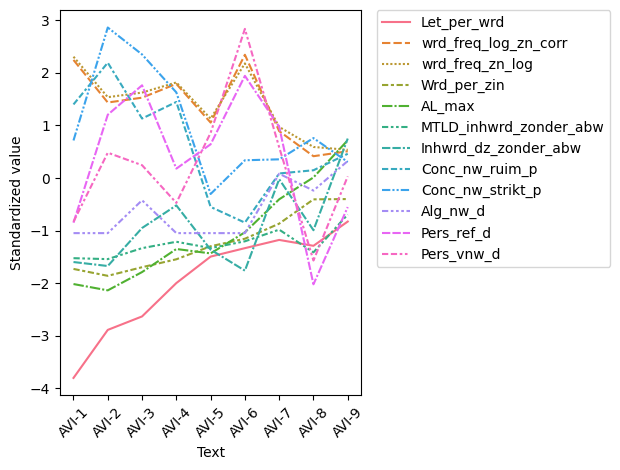

In [16]:
# Select the measures that are significantly correlated to AVI-level
sns.lineplot(df_scaled[df_scaled['Group'] == 'child texts1'].set_index('index').sort_index())
plt.xticks(np.arange(0,9,1), ['AVI-' + str(x) for x in np.arange(1,10,1)], rotation=45)
plt.xlabel('Text')
plt.ylabel('Standardized value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()  # adjusts layout so nothing is cut off
plt.show()

Comparison child texts and adult texts

In [17]:
df_wide = pd.concat([df_scaled]) # best_subset2
df_long2 = pd.melt(df_wide, id_vars=['index', 'Group'], value_vars=selectedVars)
df_long2

,index,Group,variable,value
0,input/AVI9_story1_orig.prompt.txt,child texts1,Let_per_wrd,-0.828763
1,input/AVI1_story1_orig.prompt.txt,child texts1,Let_per_wrd,-3.805588
2,input/AVI5_story1_orig.prompt.txt,child texts1,Let_per_wrd,-1.495855
3,input/AVI8_story1_orig.prompt.txt,child texts1,Let_per_wrd,-1.290541
4,input/AVI4_story1_orig.prompt.txt,child texts1,Let_per_wrd,-1.999845
...,...,...,...,...
3847,input/N00690_fn001326_orig.prompt.txt,adult texts,Pers_vnw_d,-0.609462
3848,input/N00691_fn001328_orig.prompt.txt,adult texts,Pers_vnw_d,-0.408096
3849,input/N00693_fn001193_orig.prompt.txt,adult texts,Pers_vnw_d,-0.213410
3850,input/N00519_fn001032_orig.prompt.txt,adult texts,Pers_vnw_d,-1.135040


In [18]:
df_long2['variable'].unique()

array(['Let_per_wrd', 'wrd_freq_log_zn_corr', 'wrd_freq_zn_log',
       'Wrd_per_zin', 'AL_max', 'MTLD_inhwrd_zonder_abw',
       'Inhwrd_dz_zonder_abw', 'Conc_nw_ruim_p', 'Conc_nw_strikt_p',
       'Alg_nw_d', 'Pers_ref_d', 'Pers_vnw_d'], dtype=object)

Text(0.5, 0, 'Standardized value')

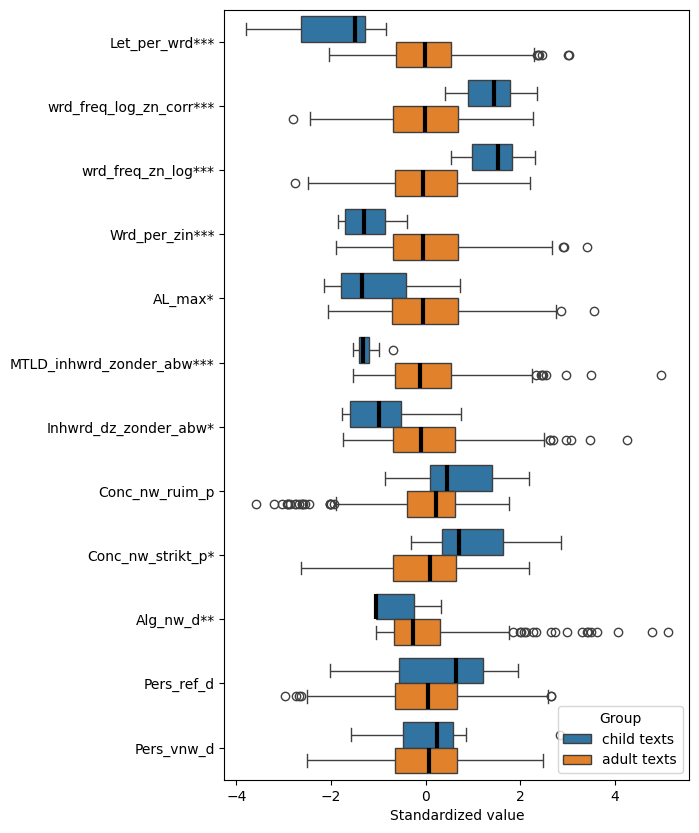

In [19]:
plt.figure(figsize=(6,10))
df_long2 = df_long2.replace('child texts1', 'child texts')
sns.boxplot(df_long2[df_long2['Group'].isin(['child texts', 'adult texts'])], hue='Group', x='value', y='variable', medianprops={"linewidth": 3, "color": "black"})

plt.yticks(np.arange(0,12,1), ['Let_per_wrd***', 'wrd_freq_log_zn_corr***', 'wrd_freq_zn_log***', 'Wrd_per_zin***', 'AL_max*', 
       'MTLD_inhwrd_zonder_abw***', 'Inhwrd_dz_zonder_abw*', 'Conc_nw_ruim_p',
       'Conc_nw_strikt_p*', 'Alg_nw_d**', 'Pers_ref_d', 'Pers_vnw_d',])


plt.ylabel('')
plt.xlabel('Standardized value')

In [20]:
for var in selectedVars:

    # Choose from: 'child texts1', 'child texts2', 'adult texts', 'adults simple', 'adults complex'
    group1 = 'adult texts'
    group2 = 'child texts' 
    var1 = df_long2[(df_long2['Group'] == group1) & (df_long2['variable'] == var)]['value']
    var2 = df_long2[(df_long2['Group'] == group2) & (df_long2['variable'] == var)]['value']
    # print(len(var1), len(var2))
    ttest_result = stats.ttest_ind(var1, var2, equal_var=False)
    print(var, ttest_result[0].round(3), ttest_result[1].round(3))

Let_per_wrd 6.034 0.0
wrd_freq_log_zn_corr -5.833 0.0
wrd_freq_zn_log -6.531 0.0
Wrd_per_zin 6.473 0.0
AL_max 3.278 0.01
MTLD_inhwrd_zonder_abw 12.094 0.0
Inhwrd_dz_zonder_abw 3.242 0.011
Conc_nw_ruim_p -1.839 0.101
Conc_nw_strikt_p -2.899 0.019
Alg_nw_d 3.236 0.009
Pers_ref_d -0.854 0.417
Pers_vnw_d -0.593 0.569
